  student_id    ug_gpa ug_university_tier    ug_major  \
0  STU100000  6.322932             Tier 3       Maths   
1  STU100001  8.197611             Tier 2       Maths   
2  STU100002  7.554681             Tier 2  Mechanical   
3  STU100003  5.944335             Tier 3         EEE   
4  STU100004  6.779260             Tier 2         ECE   

   academic_consistency_score  number_of_backlogs   gre_quant  gre_verbal  \
0                    5.233771                   0  146.898434  157.785905   
1                    6.154830                   0  168.862448  141.291206   
2                    6.615851                   0  166.237295  149.474721   
3                    5.083298                   0  157.873564  149.231949   
4                    7.763144                   0  151.626238  147.796173   

    gre_awa english_test_type  ...  application_completeness_score  \
0  3.692059             TOEFL  ...                        6.841625   
1  3.101230             TOEFL  ...                    

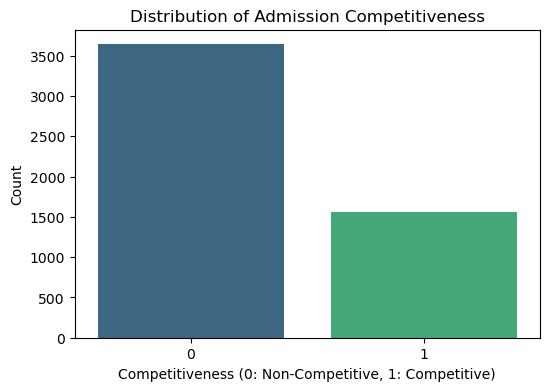

Class Balance:
admission_competitiveness
0    70.0
1    30.0
Name: proportion, dtype: float64


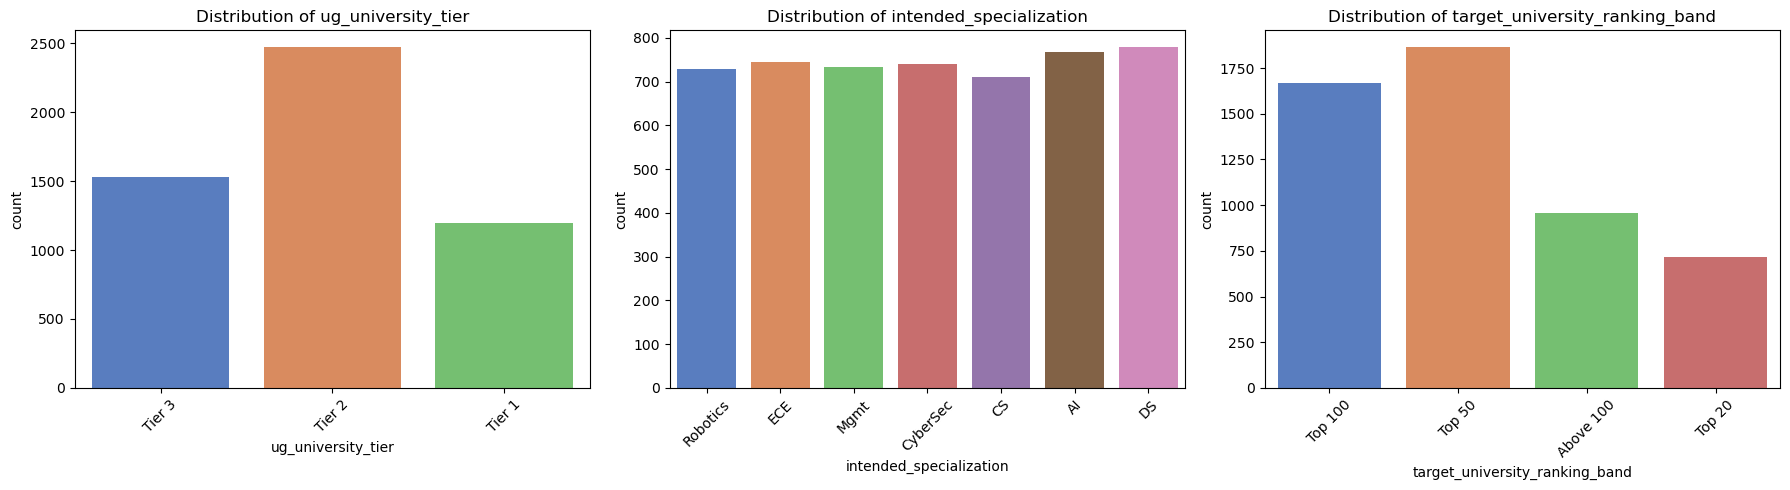

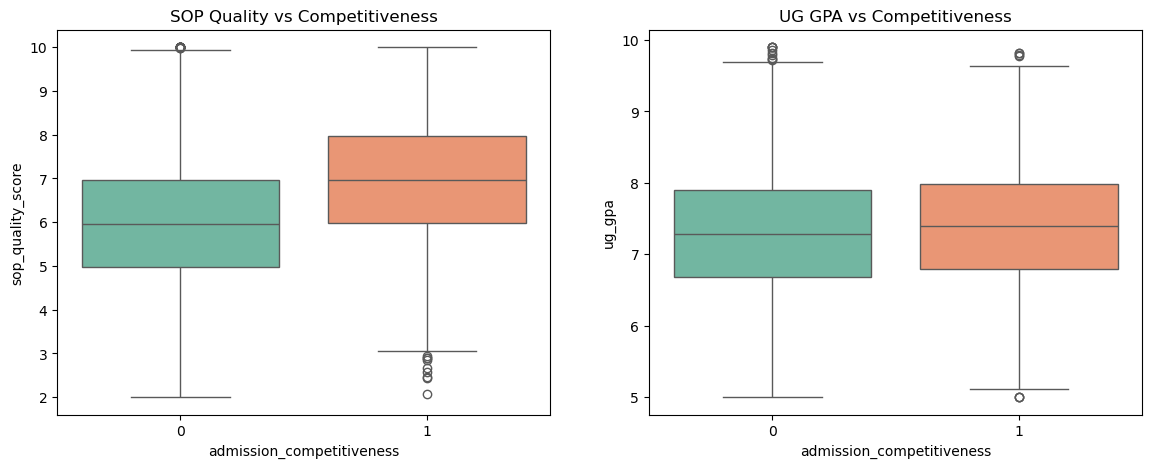

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE

df = pd.read_csv("../data/us_masters_admission_competitiveness - LMS.csv")
print(df.head())
print(df.info())
print(df.describe(include='all'))
print("\n--- Q1: Exploratory Data Analysis ---")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='admission_competitiveness', palette='viridis')
plt.title('Distribution of Admission Competitiveness')
plt.xlabel('Competitiveness (0: Non-Competitive, 1: Competitive)')
plt.ylabel('Count')
plt.show()
class_balance = df['admission_competitiveness'].value_counts(normalize=True) * 100
print(f"Class Balance:\n{class_balance.round(2)}")

categorical_features = ['ug_university_tier', 'intended_specialization', 'target_university_ranking_band']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i], palette='muted')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='admission_competitiveness', y='sop_quality_score', ax=axes[0], palette='Set2')
axes[0].set_title('SOP Quality vs Competitiveness')

sns.boxplot(data=df, x='admission_competitiveness', y='ug_gpa', ax=axes[1], palette='Set2')
axes[1].set_title('UG GPA vs Competitiveness')
plt.show()

In [ ]:
print("\n--- Q2: Data Preprocessing ---")

X = df.drop(columns=['student_id', 'admission_competitiveness'])
y = df['admission_competitiveness']

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

missing_counts = X.isnull().sum()

print("Missing values before imputation:\n", missing_counts[missing_counts > 0])




--- Q2: Data Preprocessing ---
Index(['ug_gpa', 'academic_consistency_score', 'number_of_backlogs',
       'gre_quant', 'gre_verbal', 'gre_awa', 'english_proficiency_score',
       'work_experience_months', 'project_count', 'research_exposure_level',
       'internship_relevance_score', 'field_alignment_score',
       'sop_quality_score', 'lor_strength_score', 'resume_strength_score',
       'career_goal_clarity_score', 'application_completeness_score',
       'gap_years', 'linkedin_profile_views', 'counselling_sessions_attended'],
      dtype='object')
Index(['ug_university_tier', 'ug_major', 'english_test_type',
       'intended_specialization', 'target_university_ranking_band',
       'application_round', 'visa_dependency', 'preferred_application_city'],
      dtype='object')
Missing values before imputation:
 academic_consistency_score    228
gre_awa                       220
internship_relevance_score    247
lor_strength_score            219
resume_strength_score         238
dtyp

In [32]:
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [33]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_train, y_train)

feature_importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Influential Factors:")
print(feature_importances.head(5))


Top 5 Influential Factors:
sop_quality_score             0.116222
field_alignment_score         0.084263
lor_strength_score            0.083924
ug_university_tier            0.066191
internship_relevance_score    0.064845
dtype: float64


In [38]:
print("\n--- Q3: Model Development ---")

log_reg = LogisticRegression(random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42)

log_reg.fit(X_train, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)
print("Model Sucess forlly Developed")


--- Q3: Model Development ---
Model Sucess forlly Developed


In [39]:
print("\n--- Q4: Model Evaluation & SMOTE ---")


--- Q4: Model Evaluation & SMOTE ---



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       728
           1       0.71      0.64      0.67       312

    accuracy                           0.81      1040
   macro avg       0.78      0.76      0.77      1040
weighted avg       0.81      0.81      0.81      1040


Confusion Matrix:
[[646  82]
 [113 199]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79       728
           1       0.50      0.51      0.51       312

    accuracy                           0.70      1040
   macro avg       0.65      0.65      0.65      1040
weighted avg       0.70      0.70      0.70      1040


Confusion Matrix:
[[571 157]
 [152 160]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86       728
           1       0.75      0.45

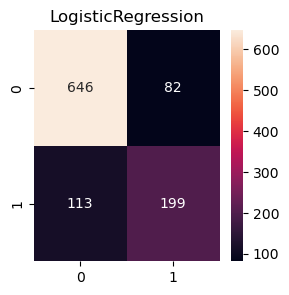

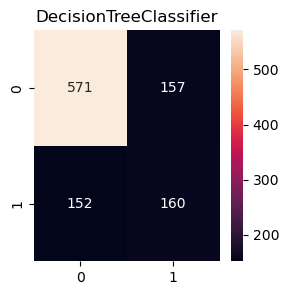

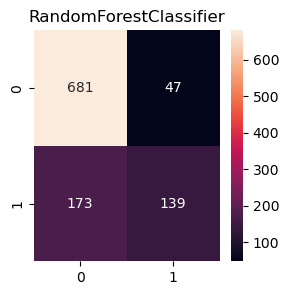

In [60]:
models = {
    'Logistic Regression': log_reg, 
    'Decision Tree': dec_tree, 
    'Random Forest': rand_forest
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    cm=np.round(confusion_matrix(y_test, y_pred),2)
    print(cm)
    plt.figure(figsize=(3,3))
    plt.title(model.__class__.__name__)
    sns.heatmap(cm,annot=True,fmt='d')


smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Class balance BEFORE SMOTE:\n{y_train.value_counts()}")
print(f"Class balance AFTER SMOTE:\n{y_train_smote.value_counts()}")


rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
print("\nRandom Forest (After SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_smote))